In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except Exception:
    HAVE_SM = False
    from scipy.stats import spearmanr
import statsmodels.formula.api as smf

Mounted at /content/drive


In [2]:
df = pd.read_excel('/content/drive/MyDrive/MSSP607/Modules/data_academic_performance.xlsx')

In [3]:
df.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [4]:
# High school (SABER 11) subjects
hs_cols = ['MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11']
# University (SABER PRO) subjects
pro_cols = ['QR_PRO','CR_PRO','CC_PRO','ENG_PRO','WC_PRO','FEP_PRO','G_SC']

print(hs_cols)
print(pro_cols)

['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11']
['QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC']


In [5]:
# Build composite means
df['HS_MEAN']  = df[hs_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
df['PRO_MEAN'] = df[pro_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
display(df['HS_MEAN'])
display(df['PRO_MEAN'])

,HS_MEAN
0,76.2
1,82.4
2,45.4
3,59.8
4,79.6
...,...
12406,70.8
12407,58.4
12408,67.6
12409,59.4


,PRO_MEAN
0,109.714286
1,111.428571
2,46.714286
3,85.428571
4,120.571429
...,...
12406,102.142857
12407,53.428571
12408,117.714286
12409,72.571429


In [6]:
# clean education of father and mother
df['EDU_FATHER'] = df['EDU_FATHER'].astype(str).str.strip()
df['EDU_MOTHER'] = df['EDU_MOTHER'].astype(str).str.strip()
# print(cat_father)
df['EDU_FATHER'] = df['EDU_FATHER'].replace('0', 'Not sure').fillna('Not sure') # Replace '0' back to 'Not sure' and fill NaN
df['EDU_MOTHER'] = df['EDU_MOTHER'].replace('0', 'Not sure').fillna('Not sure') # Replace '0' back to 'Not sure' and fill NaN
categories = {0: {'Not sure', 'Ninguno'}, 1: {'Incomplete primary'}, 2: {'Complete primary'}, 3: {'Incomplete Secundary'}, 4: {'Complete Secundary'}, 5: {'Incomplete technical or technological'}, 6:{'Complete technique or technology'}, 7: {'Incomplete Professional Education'}, 8: {'Complete professional education'}, 9: {'Postgraduate education'}}
for i in categories.keys():
    for item in categories[i]:
        df['EDU_FATHER'] = df['EDU_FATHER'].replace(item,i)
        df["EDU_MOTHER"] = df["EDU_MOTHER"].replace(item,i)

# create numerical columns for parental education
df['EDU_FATHER_NUM'] = df['EDU_FATHER'].astype(int)
df['EDU_MOTHER_NUM'] = df['EDU_MOTHER'].astype(int)
df['PARENT_EDU_MEAN'] = (df['EDU_FATHER_NUM'] + df['EDU_MOTHER_NUM']) / 2

/tmp/ipython-input-1884624363.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['EDU_FATHER'] = df['EDU_FATHER'].replace(item,i)
/tmp/ipython-input-1884624363.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["EDU_MOTHER"] = df["EDU_MOTHER"].replace(item,i)


In [7]:
print(df['EDU_FATHER'])

0        7
1        4
2        0
3        0
4        8
        ..
12406    0
12407    8
12408    6
12409    8
12410    4
Name: EDU_FATHER, Length: 12411, dtype: int64


In [8]:
# clean stratum to numerical values
df['STRATUM'] = (df['STRATUM']
                 .astype(str)
                 .str.extract(r'(\d+)', expand=False)
                 .astype('Int64'))
print(df['STRATUM'])

0        4
1        5
2        2
3        2
4        4
        ..
12406    2
12407    2
12408    2
12409    3
12410    3
Name: STRATUM, Length: 12411, dtype: Int64


In [9]:
# Anova test of parental education and outcomes
outcomes = ["HS_MEAN", "PRO_MEAN"]
parents = ["EDU_FATHER_NUM", "EDU_MOTHER_NUM", "PARENT_EDU_MEAN"]

for outcome in outcomes:
    print(f"\n=== ANOVA for {outcome} ===")
    for parent in parents:
        formula = f'{outcome} ~ C({parent})'
        try:
            model = ols(formula, data=df).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            print(f"\nANOVA for {outcome} by {parent}:")
            print(anova_table)
        except Exception as e:
            print(f"Could not perform ANOVA for {outcome} by {parent}: {e}")


=== ANOVA for HS_MEAN ===

ANOVA for HS_MEAN by EDU_FATHER_NUM:
                         sum_sq       df          F         PR(>F)
C(EDU_FATHER_NUM)  1.287098e+05      9.0  172.98065  2.582451e-310
Residual           1.025246e+06  12401.0        NaN            NaN

ANOVA for HS_MEAN by EDU_MOTHER_NUM:
                         sum_sq       df           F         PR(>F)
C(EDU_MOTHER_NUM)  1.211914e+05      9.0  161.690605  9.903394e-291
Residual           1.032765e+06  12401.0         NaN            NaN

ANOVA for HS_MEAN by PARENT_EDU_MEAN:
                           sum_sq       df           F  PR(>F)
C(PARENT_EDU_MEAN)  155510.413867     18.0  107.226947     0.0
Residual            998445.661608  12392.0         NaN     NaN

=== ANOVA for PRO_MEAN ===

ANOVA for PRO_MEAN by EDU_FATHER_NUM:
                         sum_sq       df           F         PR(>F)
C(EDU_FATHER_NUM)  3.448915e+05      9.0  102.763941  2.876493e-186
Residual           4.624406e+06  12401.0         NaN         

In [10]:
# post-hoc between parental education and outcomes
outcomes = ["HS_MEAN", "PRO_MEAN"]
parents = ["EDU_FATHER_NUM", "EDU_MOTHER_NUM", "PARENT_EDU_MEAN"]

for outcome in outcomes:
    print(f"\n=== Tukey's HSD Post-Hoc Tests for {outcome} ===")
    for parent in parents:
        formula = f'{outcome} ~ C({parent})'
        try:
            model = ols(formula, data=df).fit()
            # Perform Tukey's HSD test
            # Drop NaN values in the relevant columns before performing the test
            subset_df = df[[parent, outcome]].dropna()
            if not subset_df.empty:
                tukey_result = pairwise_tukeyhsd(endog=subset_df[outcome], groups=subset_df[parent], alpha=0.05)
                print(f"\nPost-hoc test for {outcome} by {parent}:")
                print(tukey_result)
            else:
                print(f"Not enough data to perform post-hoc test for {outcome} by {parent}")
        except Exception as e:
            print(f"Could not perform post-hoc test for {outcome} by {parent}: {e}")


=== Tukey's HSD Post-Hoc Tests for HS_MEAN ===

Post-hoc test for HS_MEAN by EDU_FATHER_NUM:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -0.3837 0.9977 -1.8067  1.0393  False
     0      2  -0.9755 0.4309 -2.3551  0.4041  False
     0      3  -0.2599 0.9998 -1.5474  1.0275  False
     0      4   0.6734  0.632 -0.4174  1.7643  False
     0      5   2.0423 0.0352  0.0707  4.0139   True
     0      6    3.251    0.0  1.9892  4.5128   True
     0      7   4.7865    0.0  3.0993  6.4736   True
     0      8   5.4329    0.0  4.3498  6.5161   True
     0      9  10.0005    0.0  8.7114 11.2896   True
     1      2  -0.5918 0.9576 -2.0515  0.8679  False
     1      3   0.1238    1.0 -1.2492  1.4967  False
     1      4   1.0571 0.1331 -0.1334  2.2477  False
     1      5    2.426  0.006  0.3975  4.4544   True
     1      6   3.6347    0.0  2.2858  4.9836   True
     

/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,



Post-hoc test for PRO_MEAN by PARENT_EDU_MEAN:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   0.0    0.5    0.788    1.0 -6.1838  7.7598  False
   0.0    1.0  -0.1507    1.0 -5.1077  4.8063  False
   0.0    1.5   2.4795 0.9818 -2.8348  7.7937  False
   0.0    2.0  -0.0373    1.0 -4.2236   4.149  False
   0.0    2.5   0.3338    1.0 -4.2123    4.88  False
   0.0    3.0   0.5438    1.0 -3.4514   4.539  False
   0.0    3.5   1.3099 0.9998 -2.7816  5.4014  False
   0.0    4.0   2.6565 0.4442 -0.8747  6.1878  False
   0.0    4.5     4.99 0.0208  0.3387  9.6413   True
   0.0    5.0   4.1386 0.0272  0.2015  8.0758   True
   0.0    5.5   7.1336    0.0  2.5116 11.7555   True
   0.0    6.0   6.0716    0.0  2.4225  9.7206   True
   0.0    6.5   8.0889    0.0  3.3679   12.81   True
   0.0    7.0  10.1511    0.0  6.1331  14.169   True
   0.0    7.5  11.8015    0.0  7.3541 16.2489   Tru

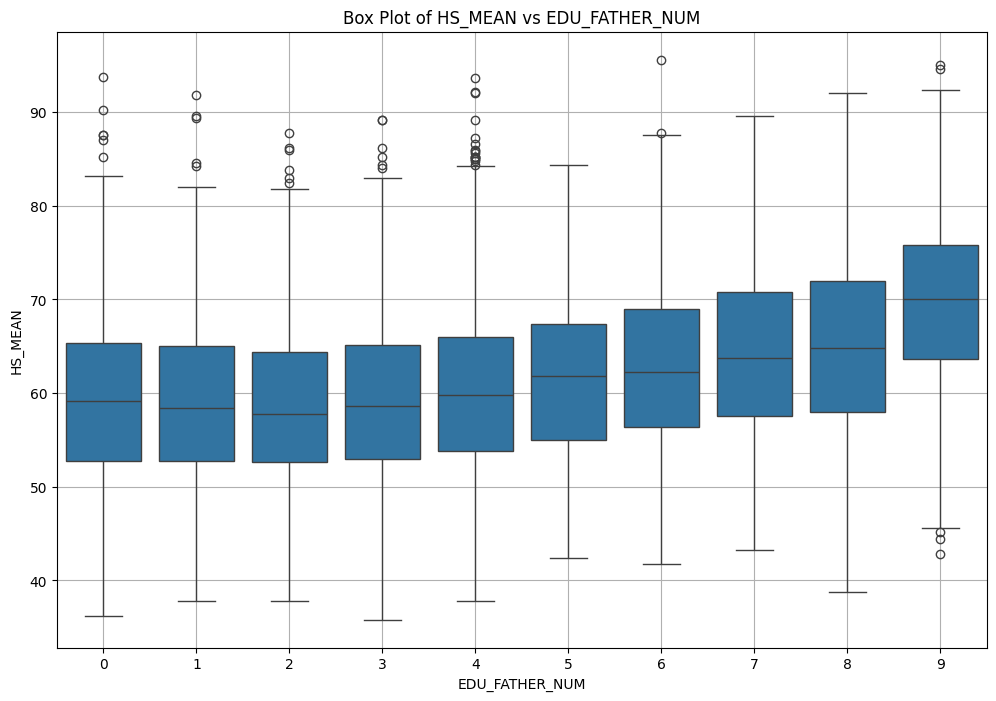

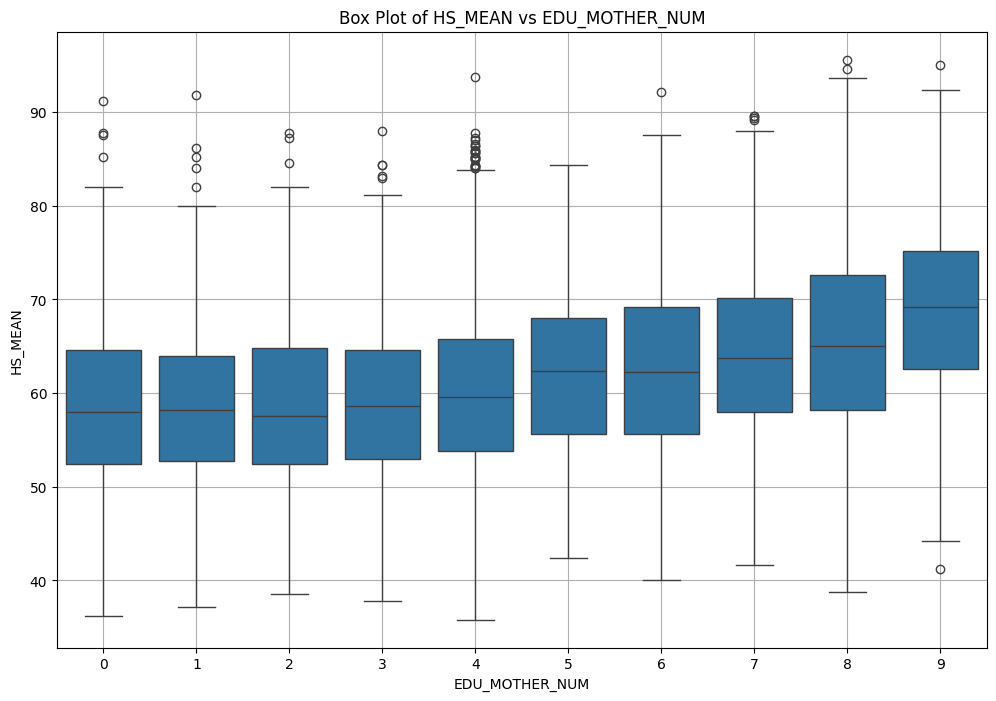

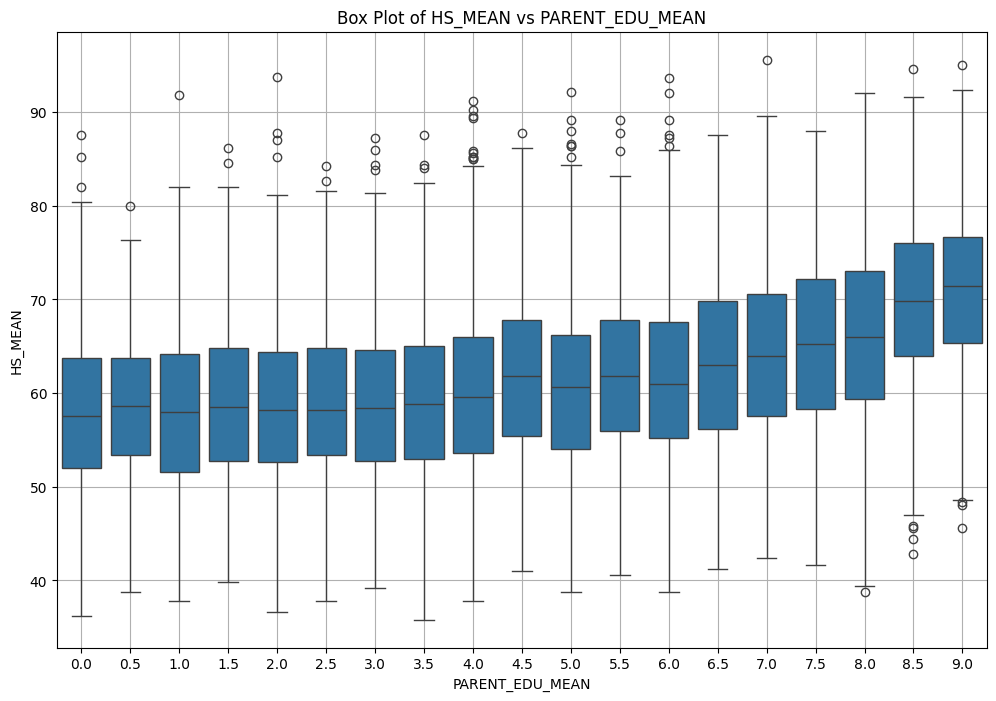

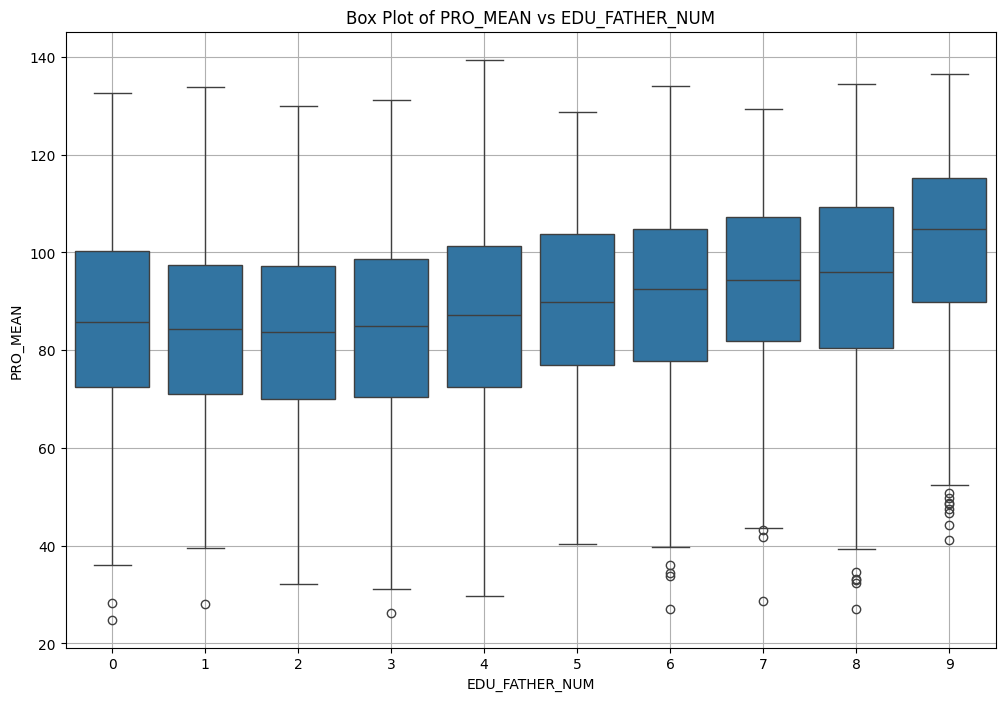

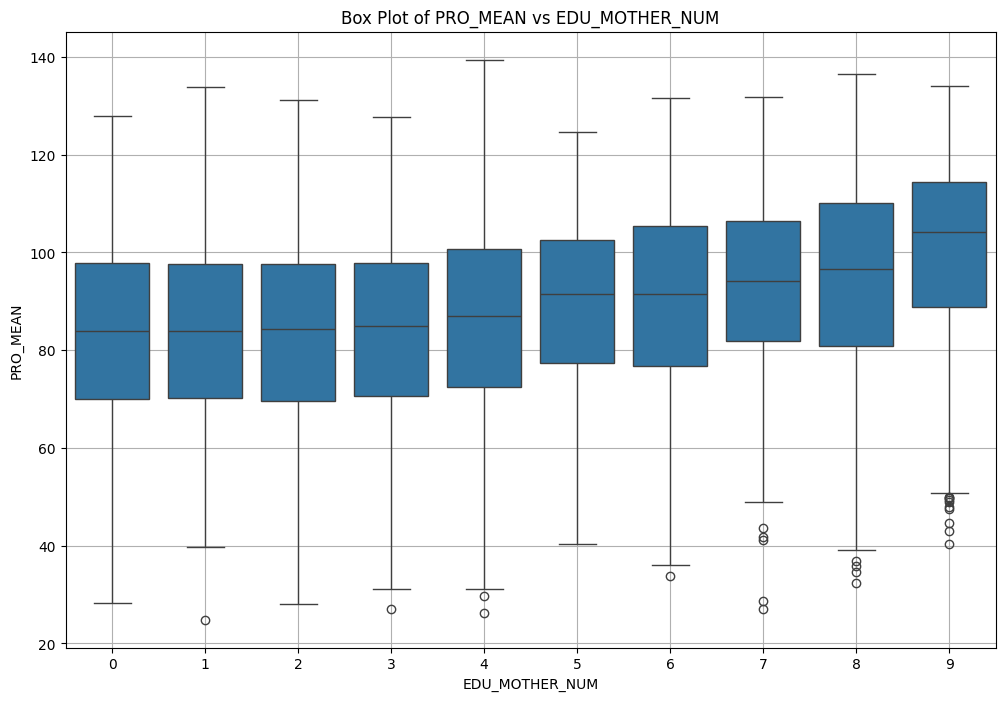

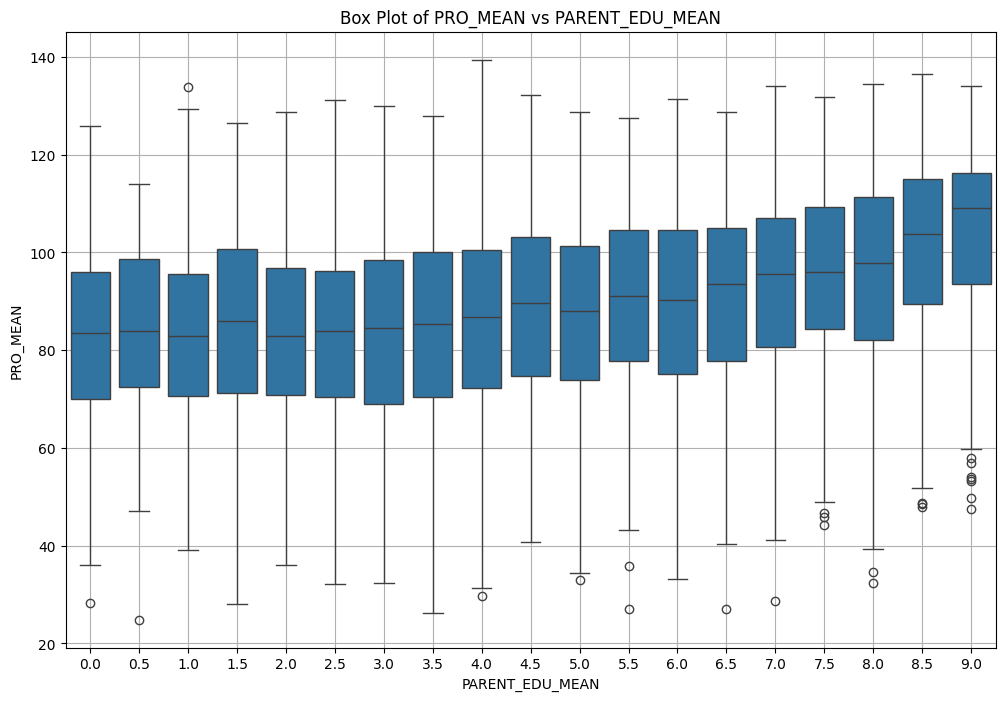

In [11]:
# plots for education and outcomes
outcomes = ["HS_MEAN", "PRO_MEAN"]
parents = ["EDU_FATHER_NUM", "EDU_MOTHER_NUM", "PARENT_EDU_MEAN"]

for outcome in outcomes:
    for parent in parents:
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=df, x=parent, y=outcome)
        plt.title(f'Box Plot of {outcome} vs {parent}')
        plt.xlabel(parent)
        plt.ylabel(outcome)
        plt.grid(True)
        plt.show()

In [12]:
# anova test between stratum and outcomes
outcomes = ["HS_MEAN", "PRO_MEAN"]
stratum_col = "STRATUM"

for outcome in outcomes:
    print(f"\n=== Analysis for {outcome} by {stratum_col} ===")
    df[stratum_col] = df[stratum_col].astype('category')
    formula = f'{outcome} ~ C({stratum_col})'
    try:
        model = ols(formula, data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print("\nANOVA Table:")
        print(anova_table)
        if anova_table['PR(>F)'][0] < 0.05:
            subset_df = df[[stratum_col, outcome]].dropna()
            if not subset_df.empty:
                 mean_by_stratum = subset_df.groupby(stratum_col)[outcome].mean().sort_values(ascending=False)
                 print(f"\nStratum with the highest mean {outcome}: {mean_by_stratum.index[0]} (Mean: {mean_by_stratum.iloc[0]:.2f})")
            else:
                 print(f"Not enough data to determine the stratum with the highest mean for {outcome}")
        else:
            print(f"\nANOVA for {outcome} by {stratum_col} is not statistically significant, skipping identification of best performing stratum.")


    except Exception as e:
        print(f"Could not perform analysis for {outcome} by {stratum_col}: {e}")


=== Analysis for HS_MEAN by STRATUM ===

ANOVA Table:
                   sum_sq       df           F  PR(>F)
C(STRATUM)  175031.288298      6.0  369.638221     0.0
Residual    978924.787177  12404.0         NaN     NaN

Stratum with the highest mean HS_MEAN: 6 (Mean: 72.48)

=== Analysis for PRO_MEAN by STRATUM ===

ANOVA Table:
                  sum_sq       df           F         PR(>F)
C(STRATUM)  4.719681e+05      6.0  216.954395  2.781480e-264
Residual    4.497330e+06  12404.0         NaN            NaN

Stratum with the highest mean PRO_MEAN: 6 (Mean: 104.99)


/tmp/ipython-input-4042484253.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
/tmp/ipython-input-4042484253.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_stratum = subset_df.groupby(stratum_col)[outcome].mean().sort_values(ascending=False)
/tmp/ipython-input-4042484253.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
/tmp/ipython-inpu

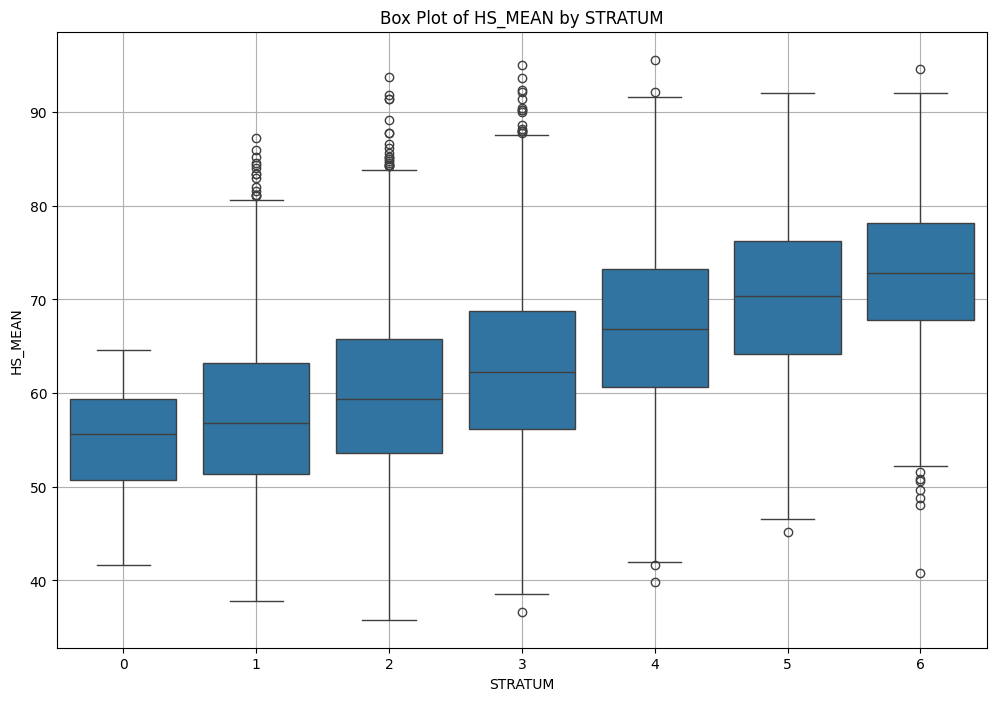

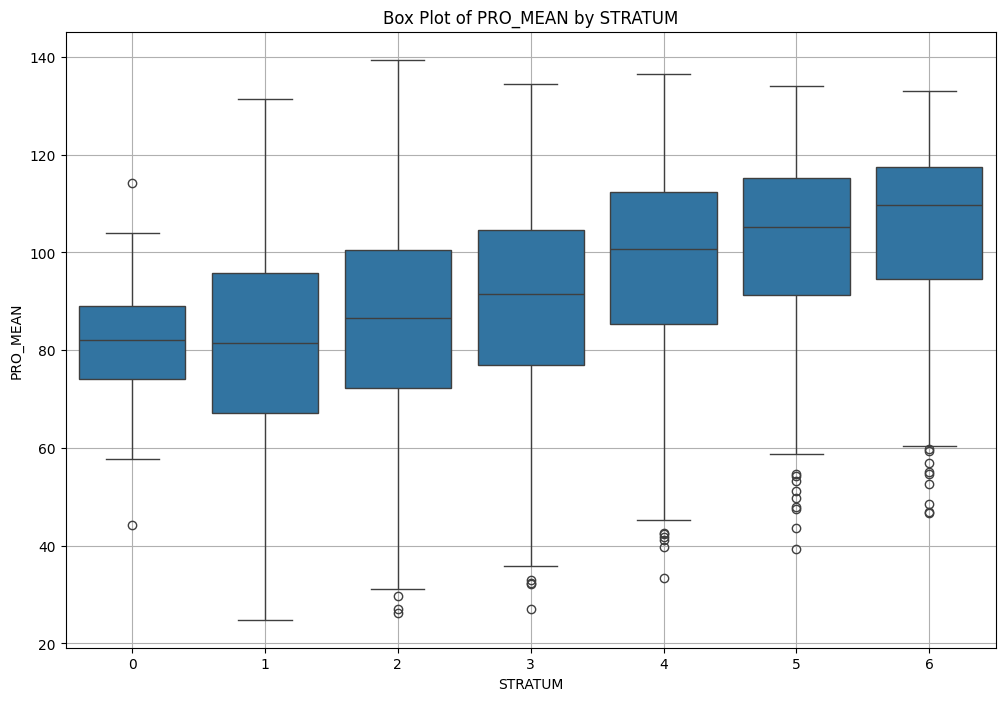

In [13]:
# plots of stratum and outcomes
outcomes = ["HS_MEAN", "PRO_MEAN"]
stratum_col = "STRATUM"

for outcome in outcomes:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df, x=stratum_col, y=outcome)
    plt.title(f'Box Plot of {outcome} by {stratum_col}')
    plt.xlabel(stratum_col)
    plt.ylabel(outcome)
    plt.grid(True)
    plt.show()

In [14]:
# Analysis of gender and global assessment
subset_df = df[['GENDER', 'G_SC']].dropna()

male_scores = subset_df[subset_df['GENDER'] == 'M']['G_SC']
female_scores = subset_df[subset_df['GENDER'] == 'F']['G_SC']

mean_male_score = male_scores.mean()
mean_female_score = female_scores.mean()

print(f"Mean G_SC score for Males: {mean_male_score:.2f}")
print(f"Mean G_SC score for Females: {mean_female_score:.2f}")

if len(male_scores) > 1 and len(female_scores) > 1:
    ttest_result = ttest_ind(male_scores, female_scores)
    print(f"\nIndependent Samples t-test results:")
    print(f"  t-statistic: {ttest_result.statistic:.2f}")
    print(f"  p-value: {ttest_result.pvalue:.3g}")

Mean G_SC score for Males: 163.69
Mean G_SC score for Females: 161.28

Independent Samples t-test results:
  t-statistic: 5.72
  p-value: 1.1e-08


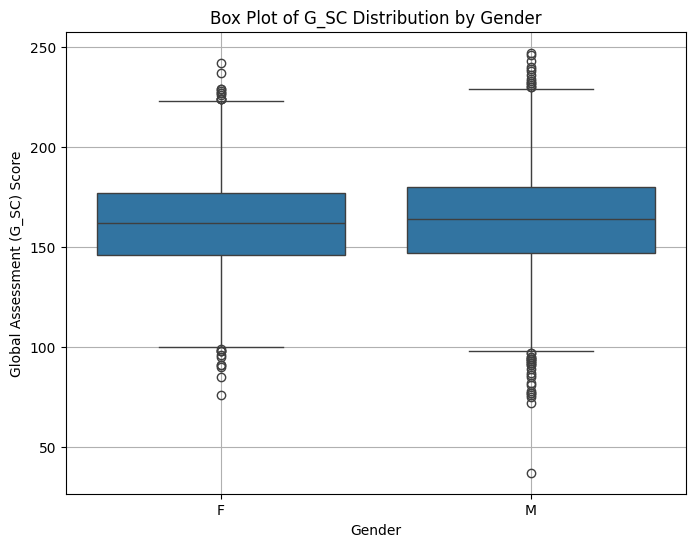

In [15]:
# plot of gender and G_SC
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='GENDER', y='G_SC')
plt.title('Box Plot of G_SC Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Global Assessment (G_SC) Score')
plt.grid(True)
plt.show()